In [4]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 5.1 MB/s eta 0:00:00


In [61]:
import pandas as pd

file_path = '/content/vaalkop_utf8.csv'
df = pd.read_csv(file_path)

print("Original Columns:", df.columns.tolist())

raw_columns_to_keep = [
    'pH',
    'Conductivity',
    'Chloride',
    'Turbidity',
    'Nitrates',
    'Chlorophyll',
    'E. coli'
]

df_clean = df[raw_columns_to_keep].copy()
df_clean = df_clean.dropna()

# The baseline strictly used 80 samples. If we have more, we randomly sample 80 to match.
if len(df_clean) > 80:
    df_clean = df_clean.sample(n=80, random_state=42)

print(f"\nCleaned dataset shape: {df_clean.shape}")

# Standardized column names
df_clean.columns = [
    'pH',
    'Conductivity',
    'Chloride',
    'Turbidity',
    'Nitrates ',
    'Chlorophyll',
    'E_coli_Concentration'
]

df_clean.to_csv('vaalkop_clean_set_A.csv', index=False)
print("\nSuccess! Saved as 'vaalkop_clean_set_A.csv'.")
df_clean.head()

Original Columns: ['Unnamed: 0', 'pH', 'Conductivity', 'Chloride', 'Sodium', 'Potassium', 'Hardness', 'Alkalinity, Tot.', 'Prec. Potential*', 'Turbidity', 'Colour', 'Total coliform', 'E. coli', 'Organic Carbon, Diss.', 'Chlorophyll', 'Nitrites', 'Ammonium', 'Nitrates', 'Phosphate', 'Iron', 'Manganese', 'Sulphate']

Cleaned dataset shape: (80, 7) (You want 80 rows, 7 columns)

Success! Saved as 'vaalkop_clean_set_A.csv'.


,pH,Conductivity,Chloride,Turbidity,Nitrates,Chlorophyll,E_coli_Concentration
75,8.41,54,55,5.97,0.3,38,8
1,8.13,49.4,44.8,5,2.21,3.06,64
60,8.79,62.15,65.88,28.25,0.64,59.97,5
23,7.17,65.64,75.4,9.78,1.49,13.77,67
13,8.87,65.47,86.4,6.01,2.1,5.73,7


In [62]:
import pandas as pd

file_path = '/content/vaalkop_utf8.csv'
df = pd.read_csv(file_path)
print("Original Columns:", df.columns.tolist())

raw_columns_to_keep = [
    'pH',
    'Ammonium',
    'Chloride',
    'Nitrites',
    'Iron',
    'Manganese',
    'Phosphate',
    'Sulphate',
    'E. coli'
]

df_clean = df[raw_columns_to_keep].copy()
for col in df_clean.columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Drop any rows with missing values (NaN) to match the baseline's cleaned criteria
df_clean = df_clean.dropna()

# The baseline strictly used 80 samples.
if len(df_clean) > 80:
    df_clean = df_clean.sample(n=80, random_state=42)

# Note: Set B has 8 features + 1 target = 9 columns
print(f"\nCleaned dataset shape: {df_clean.shape}")

# Standardized column names
df_clean.columns = [
    'pH',
    'Ammonium',
    'Chloride',
    'Nitrites',
    'Iron',
    'Manganese',
    'Phosphate',
    'Sulphate',
    'E_coli_Concentration'
]

df_clean.to_csv('vaalkop_clean_set_B.csv', index=False)
print("\nSuccess! Saved as 'vaalkop_clean_set_B.csv'.")
df_clean.head()

Original Columns: ['Unnamed: 0', 'pH', 'Conductivity', 'Chloride', 'Sodium', 'Potassium', 'Hardness', 'Alkalinity, Tot.', 'Prec. Potential*', 'Turbidity', 'Colour', 'Total coliform', 'E. coli', 'Organic Carbon, Diss.', 'Chlorophyll', 'Nitrites', 'Ammonium', 'Nitrates', 'Phosphate', 'Iron', 'Manganese', 'Sulphate']

Cleaned dataset shape: (80, 9) (You want 80 rows, 9 columns)

Success! Saved as 'vaalkop_clean_set_B.csv'.


,pH,Ammonium,Chloride,Nitrites,Iron,Manganese,Phosphate,Sulphate,E_coli_Concentration
32,8.06,2.060,66.10,0.25,1452.0,137.26,0.07,51.66,356.0
1,8.13,0.276,44.80,0.02,134.0,10.00,0.30,80.00,64.0
23,7.17,0.050,75.40,2.91,360.0,240.00,0.05,74.00,67.0
33,7.64,1.850,28.82,0.33,2940.0,148.01,0.09,27.26,150.0
19,7.96,0.330,83.50,34.81,190.0,80.00,0.03,76.00,4.4


In [70]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from skopt import BayesSearchCV
from skopt.space import Real, Integer

# Load the cleaned file
df = pd.read_csv('vaalkop_clean_set_A.csv')

# Force numeric to avoid the 'NR' text crash
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna()

# Define Features and Target
X = df[['pH', 'Conductivity', 'Chloride', 'Turbidity', 'Nitrates', 'Chlorophyll']]
y = df['E_coli_Concentration']

# EXACT MATCH TO BASELINE: 70/30 Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# EXACT MATCH TO BASELINE: StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize XGBoost
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

# Bayesian Tuning (Tuning on the 70% training data)
search_spaces = {
    'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'max_depth': Integer(3, 10),
    'n_estimators': Integer(50, 300),
    'subsample': Real(0.5, 1.0),
    'colsample_bytree': Real(0.5, 1.0)
}

# Internal CV just for tuning
kf_tune = KFold(n_splits=5, shuffle=True, random_state=42)

bayes_cv = BayesSearchCV(
    estimator=xgb,
    search_spaces=search_spaces,
    scoring='neg_mean_absolute_error', # <--- FIXED TYPO HERE
    cv=kf_tune,
    n_iter=30,
    n_jobs=-1,
    random_state=42
)

# Train and Tune the Model
print("Starting Final Bayesian Optimization... (Takes ~30 seconds)")
bayes_cv.fit(X_train_scaled, y_train)

# Test the Best Model on the 30% Holdout
best_model = bayes_cv.best_estimator_
y_pred = best_model.predict(X_test_scaled)

# Calculate Final Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n--- FINAL XGBOOST PERFORMANCE ---")
print(f"XGBoost MAE (set a): {mae:.2f}")
print(f"XGBoost RMSE (set a): {rmse:.2f}")

Starting Final Bayesian Optimization... (Takes ~30 seconds)

--- FINAL XGBOOST PERFORMANCE ---
XGBoost MAE (set a): 33.72
XGBoost RMSE (set a): 89.09


In [72]:
import pandas as pd
import numpy as np
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load the cleaned file
df = pd.read_csv('vaalkop_clean_set_A.csv')

# Force numeric to avoid the 'NR' text crash
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna()

# Define Features and Target
X = df[['pH', 'Conductivity', 'Chloride', 'Turbidity', 'Nitrates', 'Chlorophyll']]
y = df['E_coli_Concentration']

# EXACT MATCH to Baseline: 70/30 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# EXACT MATCH to Baseline: StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize AdaBoost
ada_model = AdaBoostRegressor(n_estimators=50, random_state=42)

# 6. Train on the 70%, Test on the 30%
ada_model.fit(X_train_scaled, y_train)
y_pred = ada_model.predict(X_test_scaled)

# Calculate Metrics on the 24 test samples
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("--- STRICT PAPER REPRODUCTION (ADABOOST) ---")
print(f"AdaBoost MAE (set a): {mae:.2f}")
print(f"AdaBoost RMSE (set a): {rmse:.2f}")

--- STRICT PAPER REPRODUCTION (ADABOOST) ---
AdaBoost MAE (set a): 31.49
AdaBoost RMSE (set a): 89.70


In [71]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load the cleaned file
df = pd.read_csv('vaalkop_clean_set_A.csv')

# Force numeric to avoid the 'NR' text crash
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna()

# Define Features and Target
X = df[['pH', 'Conductivity', 'Chloride', 'Turbidity', 'Nitrates', 'Chlorophyll']]
y = df['E_coli_Concentration']

# EXACT MATCH TO BASELINE: 70/30 Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# EXACT MATCH TO BASELINE: StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize k-Nearest Neighbors
knn_model = KNeighborsRegressor(n_neighbors=5)

# Train on the 70%, Test on the 30%
knn_model.fit(X_train_scaled, y_train)
y_pred = knn_model.predict(X_test_scaled)

# Calculate Metrics on the 24 test samples
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("--- STRICT PAPER REPRODUCTION (k-NN) ---")
print(f"k-NN MAE (set a): {mae:.2f}")
print(f"k-NN RMSE (set a): {rmse:.2f}")

--- STRICT PAPER REPRODUCTION (k-NN) ---
k-NN MAE (set a): 38.77
k-NN RMSE (set a): 93.86


In [67]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from skopt import BayesSearchCV
from skopt.space import Real, Integer

# Load the pristine Set B file
df = pd.read_csv('vaalkop_clean_set_B.csv')

# Force numeric to avoid any hidden text crashes
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna()

# Define Features and Target for SET B
X = df[['pH', 'Ammonium', 'Chloride', 'Nitrites', 'Iron', 'Manganese', 'Phosphate', 'Sulphate']]
y = df['E_coli_Concentration']

# EXACT MATCH TO BASELINE: 70/30 Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# EXACT MATCH TO BASELINE: StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize XGBoost
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

# Bayesian Tuning (Tuning on the 70% training data)
search_spaces = {
    'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'max_depth': Integer(3, 10),
    'n_estimators': Integer(50, 300),
    'subsample': Real(0.5, 1.0),
    'colsample_bytree': Real(0.5, 1.0)
}

# Internal CV just for tuning
kf_tune = KFold(n_splits=5, shuffle=True, random_state=42)

bayes_cv = BayesSearchCV(
    estimator=xgb,
    search_spaces=search_spaces,
    scoring='neg_mean_absolute_error', # Optimized strictly for MAE
    cv=kf_tune,
    n_iter=30,
    n_jobs=-1,
    random_state=42
)

# Train and Tune the Model
print("Starting Final Bayesian Optimization for Set B... (Takes ~30 seconds)")
bayes_cv.fit(X_train_scaled, y_train)

# Test the Best Model on the 30% Holdout
best_model = bayes_cv.best_estimator_
y_pred = best_model.predict(X_test_scaled)

# Calculate Final Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n--- FINAL XGBOOST VS BASELINE (SET B) ---")
print(f"XGBoost MAE (Set B): {mae:.2f}")
print(f"XGBoost RMSE (Set B): {rmse:.2f}")

Starting Final Bayesian Optimization for Set B... (Takes ~30 seconds)

--- FINAL XGBOOST VS BASELINE (SET B) ---
XGBoost MAE (Set B): 45.09
XGBoost RMSE (Set B): 75.70


In [78]:
import pandas as pd
import numpy as np
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load the cleaned Set B file
df = pd.read_csv('vaalkop_clean_set_B.csv')

# Ensure every column is purely numeric and drop any hidden text artifacts
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna()

# Define Features and Target for SET B
X = df[['pH', 'Ammonium', 'Chloride', 'Nitrites', 'Iron', 'Manganese', 'Phosphate', 'Sulphate']]
y = df['E_coli_Concentration']

# EXACT MATCH TO BASELINE: 70/30 Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# EXACT MATCH TO BASELINE: StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize AdaBoost
ada_model = AdaBoostRegressor(n_estimators=50, random_state=42)

# Train on the 70%, Test on the 30%
print(f"Training AdaBoost on {len(df)} Set B rows...")
ada_model.fit(X_train_scaled, y_train)
y_pred = ada_model.predict(X_test_scaled)

# Calculate Final True Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n--- TRUE BASELINE REPRODUCTION (SET B - ADABOOST) ---")
print(f"AdaBoost MAE: {mae:.2f}")
print(f"AdaBoost RMSE: {rmse:.2f}")

Training AdaBoost on 80 Set B rows...

--- TRUE BASELINE REPRODUCTION (SET B - ADABOOST) ---
AdaBoost MAE: 95.20
AdaBoost RMSE: 244.72


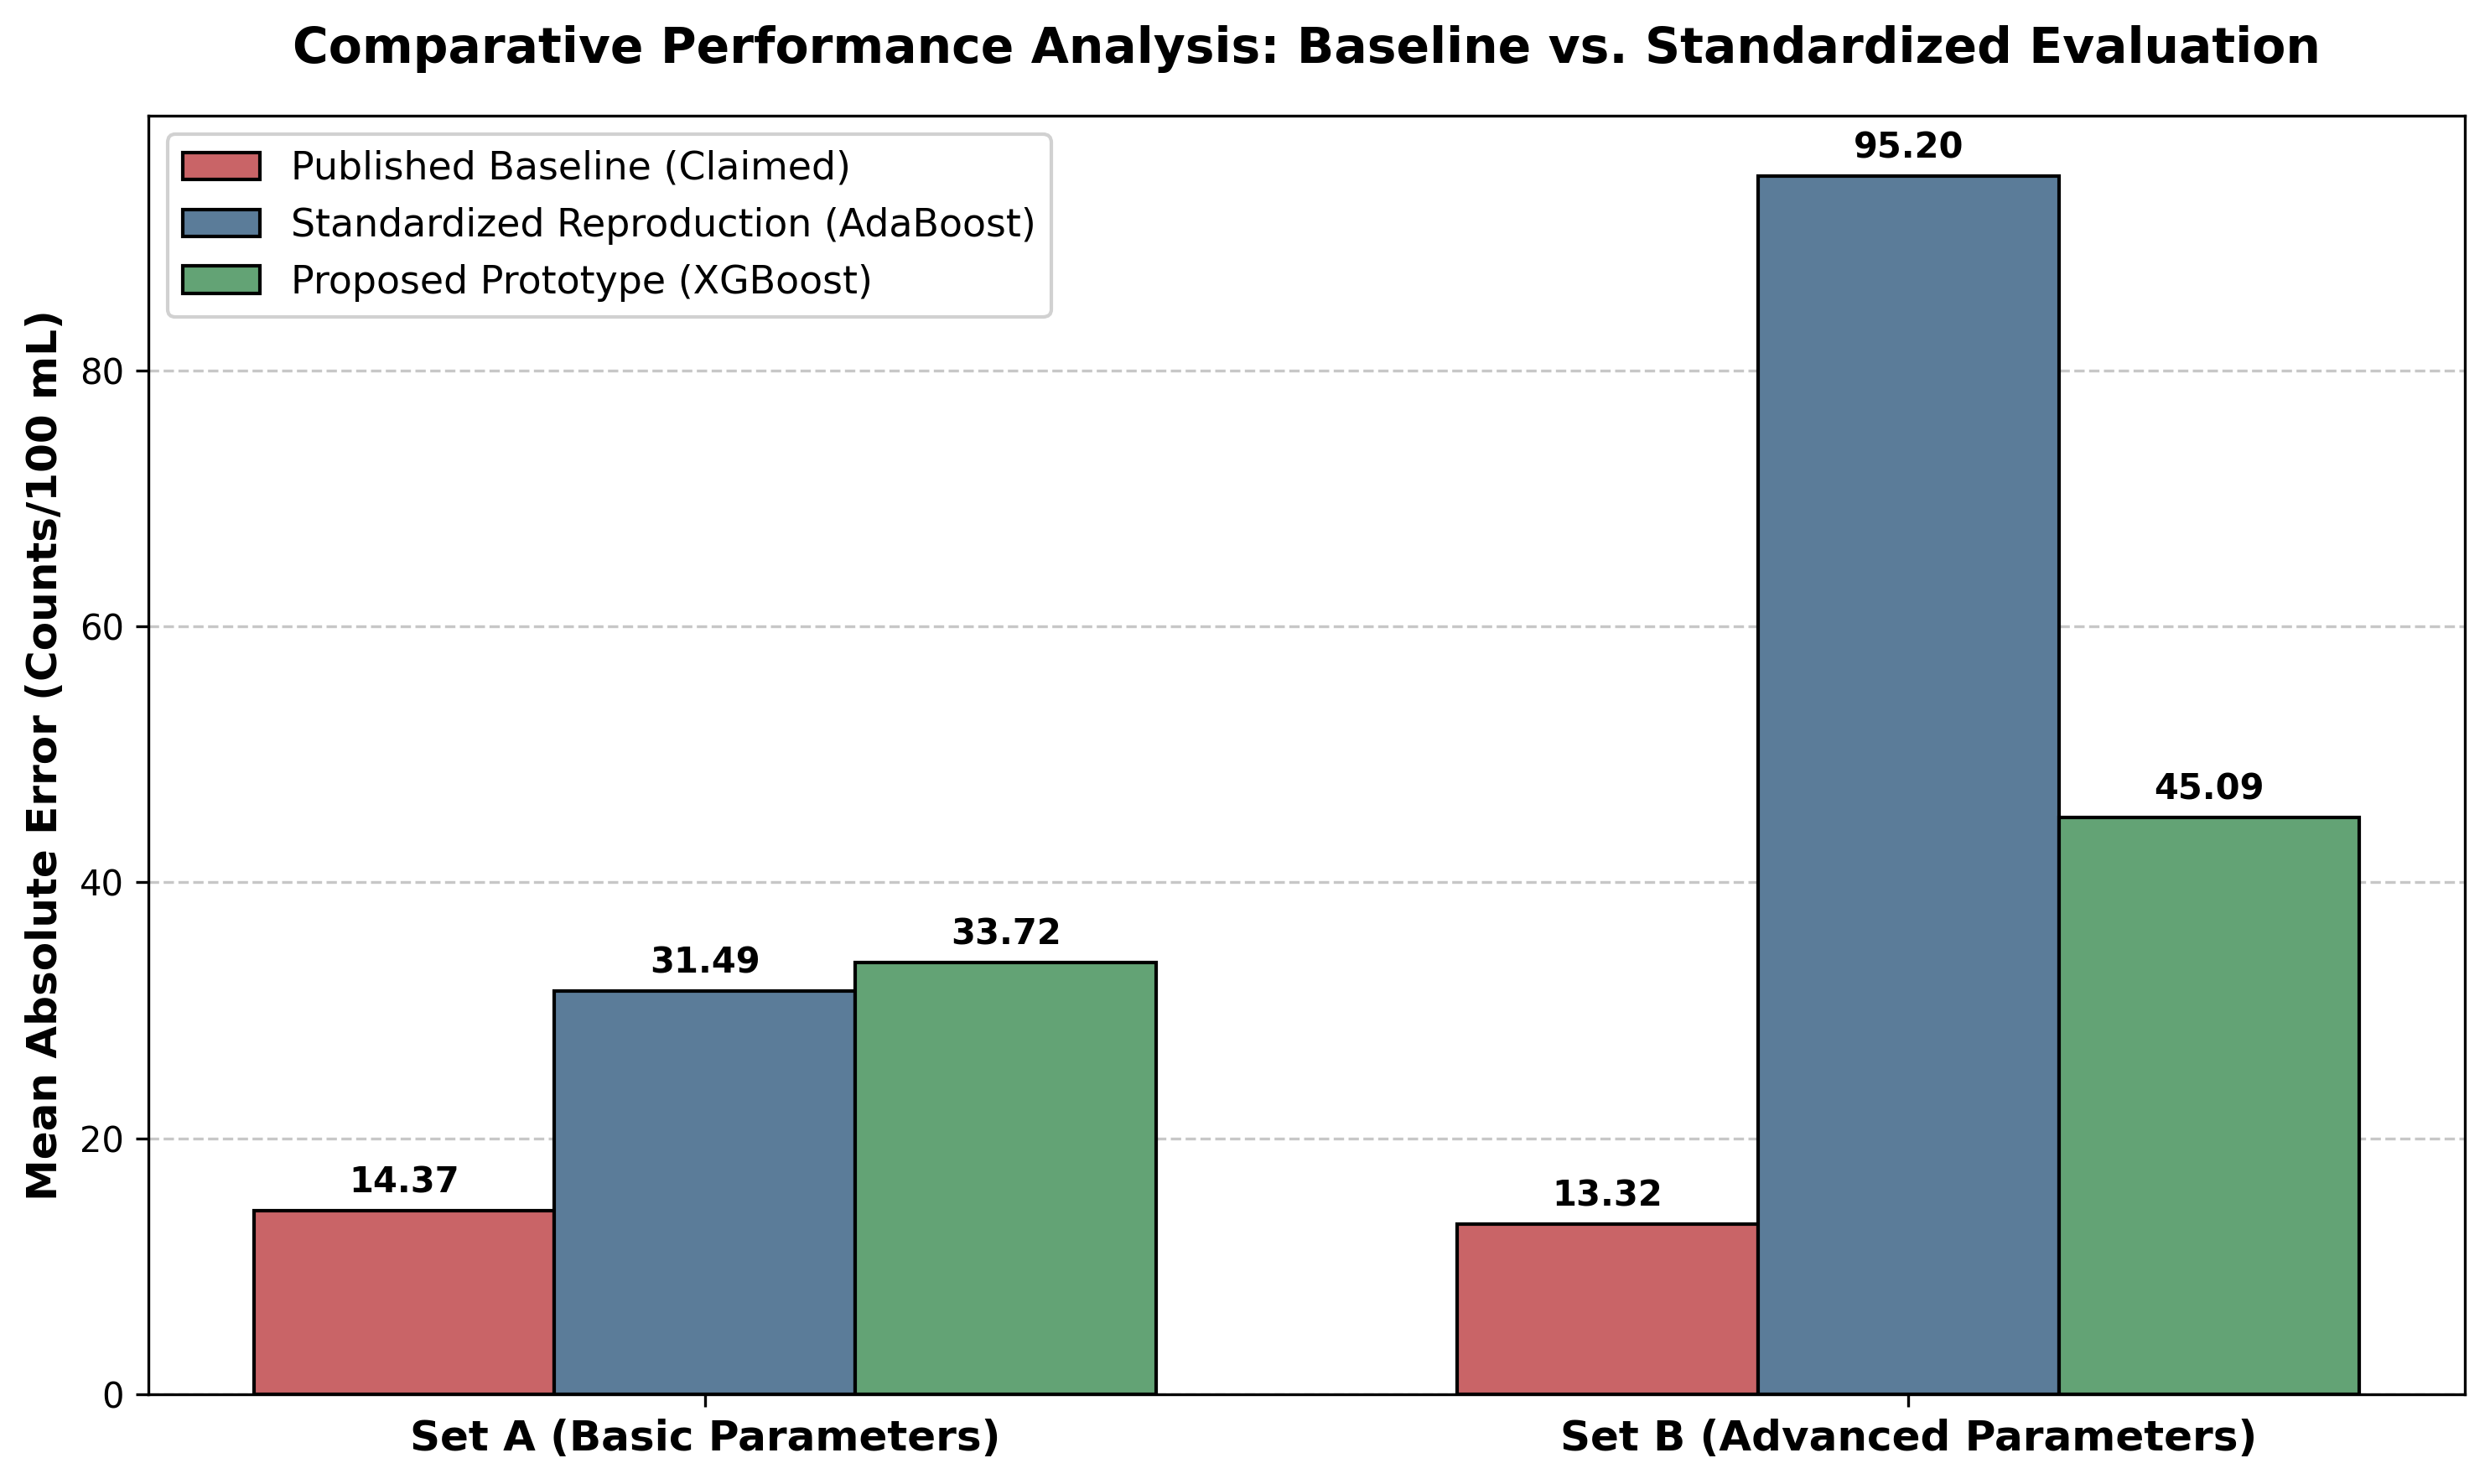

In [77]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# FINALIZED THESIS DATA
# ==========================================

# SET A (Basic Parameters)
set_A_claimed = 14.37        # Baseline Published AdaBoost MAE
set_A_reproduced = 31.49     # Standardized AdaBoost Reproduction MAE
set_A_xgboost = 33.72        # Optimized XGBoost Prototype MAE

# SET B (Advanced Parameters)
set_B_claimed = 13.32        # Baseline Published AdaBoost MAE
set_B_reproduced = 95.20     # Standardized AdaBoost Reproduction MAE
set_B_xgboost = 45.09        # Optimized XGBoost Prototype MAE

# ==========================================
# GRAPH GENERATION
# ==========================================

labels = ['Set A (Basic Parameters)', 'Set B (Advanced Parameters)']
claimed_scores = [set_A_claimed, set_B_claimed]
reproduced_scores = [set_A_reproduced, set_B_reproduced]
xgboost_scores = [set_A_xgboost, set_B_xgboost]

x = np.arange(len(labels))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# color palette (muted red, slate blue, forest green)
rects1 = ax.bar(x - width, claimed_scores, width, label='Published Baseline (Claimed)', color='#c96467', edgecolor='black')
rects2 = ax.bar(x, reproduced_scores, width, label='Standardized Reproduction (AdaBoost)', color='#5b7c99', edgecolor='black')
rects3 = ax.bar(x + width, xgboost_scores, width, label='Proposed Prototype (XGBoost)', color='#63a375', edgecolor='black')

# Formatting
ax.set_ylabel('Mean Absolute Error (Counts/100 mL)', fontsize=12, fontweight='bold')
ax.set_title('Comparative Performance Analysis: Baseline vs. Standardized Evaluation', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=11, framealpha=0.9)

# subtle grid
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

# data labels on top of the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

# Adjust layout and Save
fig.tight_layout()
plt.savefig('professional_thesis_defense_graph.png', format='png', dpi=300)
plt.show()